# **Лабораторная №1**
# *Исмаилова Камила М80-308Б-23*

**ПОДГОТОВКА - БАЗОВЫЕ ШТУЧКИ** 🦊





**Импорт необходимых библиотек, инструментов**


In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.interpolate import make_interp_spline
import statsmodels.api as sm
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
warnings.filterwarnings('ignore')

**Загрузка данных**



In [ ]:
df_train = pd.read_csv("train_c.csv")
df_train_test = pd.read_csv("test_c.csv")
test_id = df_train_test['ID'].copy()

df_train.drop_duplicates(inplace=True)
df_train.dropna(inplace=True)

df_train_original = df_train.copy()
print(f"После очистки данных: {df_train.shape}")


После очистки данных: (9529, 35)


работа с пропусками другими способами : средним, медианой или модой давали либо Такой же MSE, либо хуже.


**Проверка на диссбаланс**


Посмотрим на это визуально


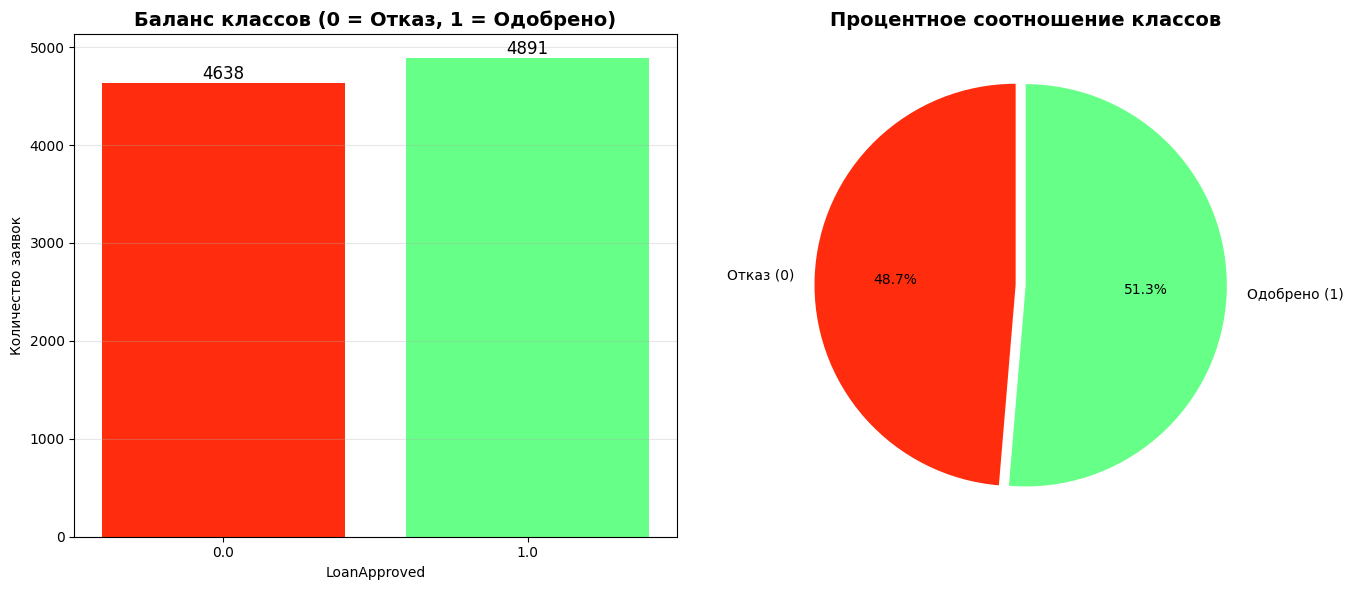

In [81]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

class_counts = df_train['LoanApproved'].value_counts().sort_index()
bars = ax[0].bar(class_counts.index.astype(str), class_counts.values, color=["#ff2d0d", "#66ff87"])
ax[0].set_title('Баланс классов (0 = Отказ, 1 = Одобрено)', fontsize=14, fontweight='bold')
ax[0].set_xlabel('LoanApproved')
ax[0].set_ylabel('Количество заявок')
ax[0].grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2., height,
               f'{int(height)}', ha='center', va='bottom', fontsize=12)
ax[1].pie(class_counts.values, labels=['Отказ (0)', 'Одобрено (1)'], autopct='%1.1f%%',
          startangle=90, colors=['#ff2d0d', '#66ff87'], explode=(0.05, 0))
ax[1].set_title('Процентное соотношение классов', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()



количество откащов и одобрений примерно равно. Нас интересует скорее не то что они примерно равны, а то что нет большего числа 0 или 1. В ином случаем моедль бы могла условно обмануться при большом количестве 0 - предсказывать тоже часто ноль. Так же мы теперь можем доверять ROC-AUC.

In [82]:
df_train.shape

(9529, 35)

**Кореляционная матрица и другие графики** 🦊

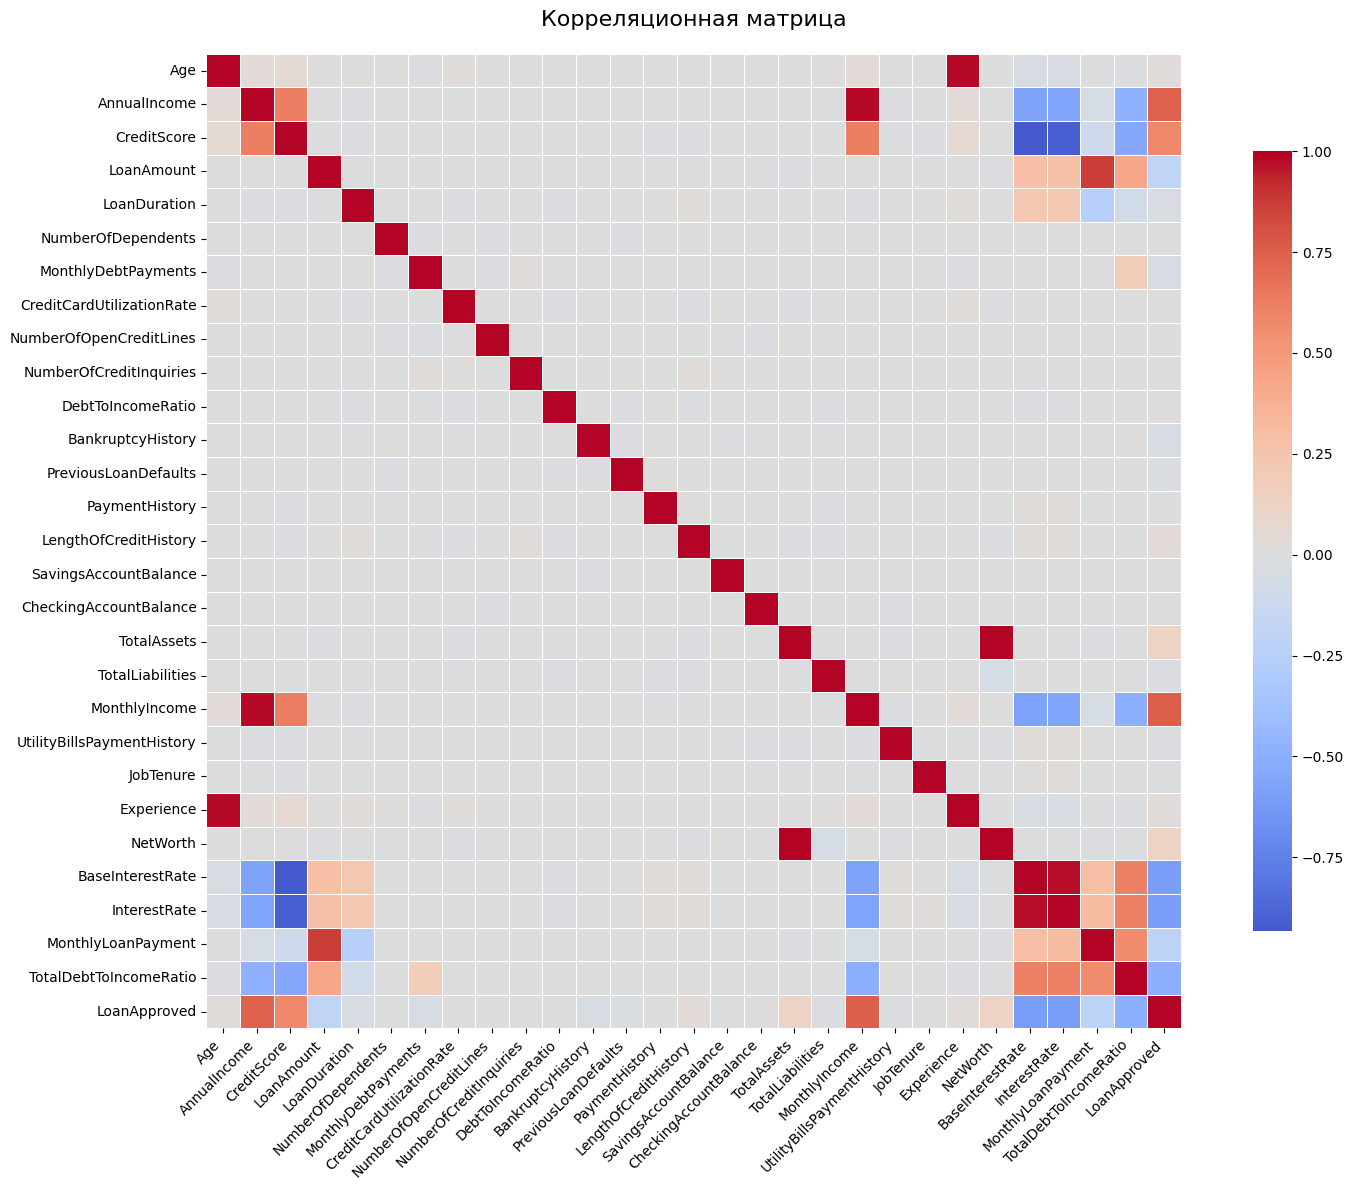

In [83]:
numeric_df_train = df_train.select_dtypes(include='number')

plt.figure(figsize=(16, 12))
heatmap = sns.heatmap(numeric_df_train.corr(), 
                     annot=False, 
                     cmap='coolwarm', 
                     center=0,
                     square=True,
                     linewidths=0.5,
                     cbar_kws={"shrink": .8})
plt.title('Корреляционная матрица', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

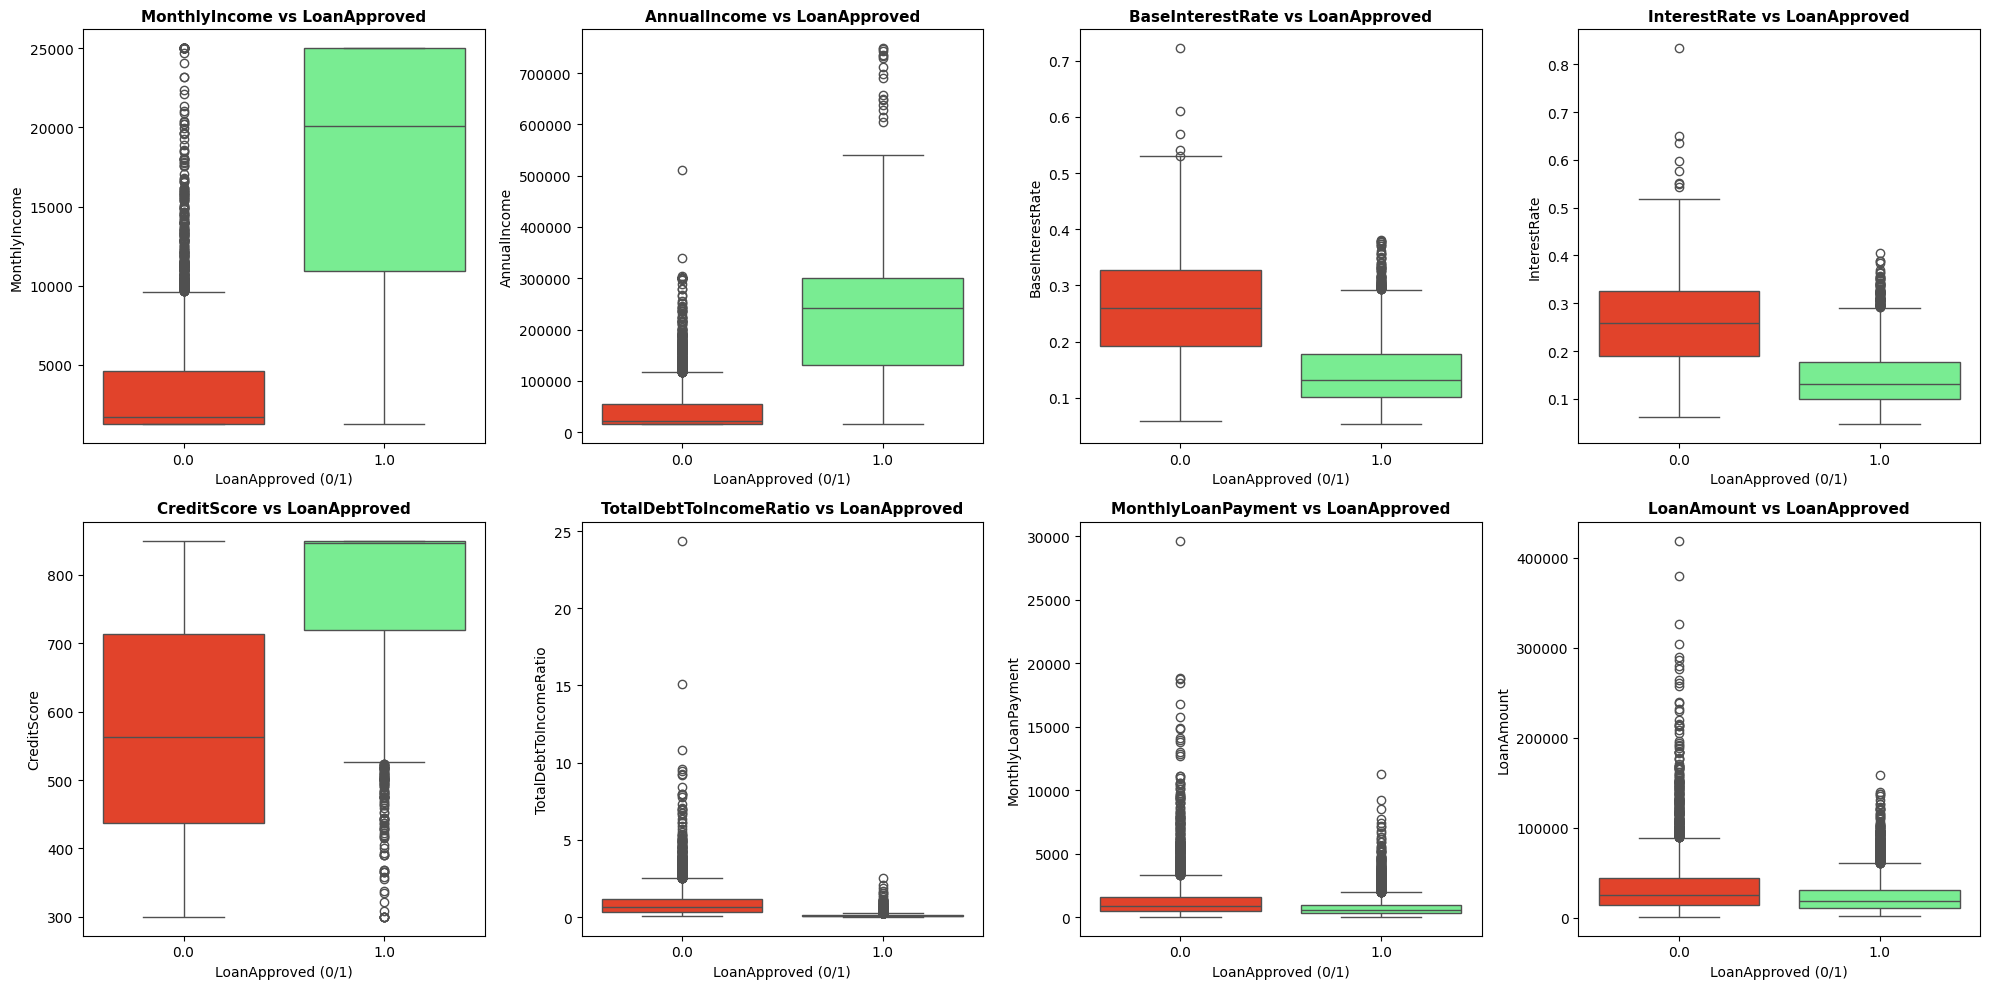

In [84]:
numeric_df = df_train.select_dtypes(include='number')
top_corr_features = numeric_df.corr()['LoanApproved'].abs().sort_values(ascending=False).index[1:9]

n_cols = 4
n_rows = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 10))
axes = axes.flatten()

for idx, col in enumerate(top_corr_features):
    sns.boxplot(x='LoanApproved', y=col, data=df_train, ax=axes[idx], palette=['#ff2d0d', '#66ff87'])
    axes[idx].set_title(f'{col} vs LoanApproved', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('LoanApproved (0/1)')
    axes[idx].set_ylabel(col)

plt.tight_layout()
plt.show()



выводится топ 8 признаков по корреляции. далее по идее модель автоматически должна выбрать то, что ей нужно данные boxlpot для демонстрации- есть ли числовые признаки, которые реально различаются для одобренных и неодобренных кредитов?

н: 
   - У одобренных выше доходы (MonthlyIncome, AnnualIncome).
   - У одобренных выше CreditScore.
   - У одобренных ниже процентные ставки (BaseInterestRate).

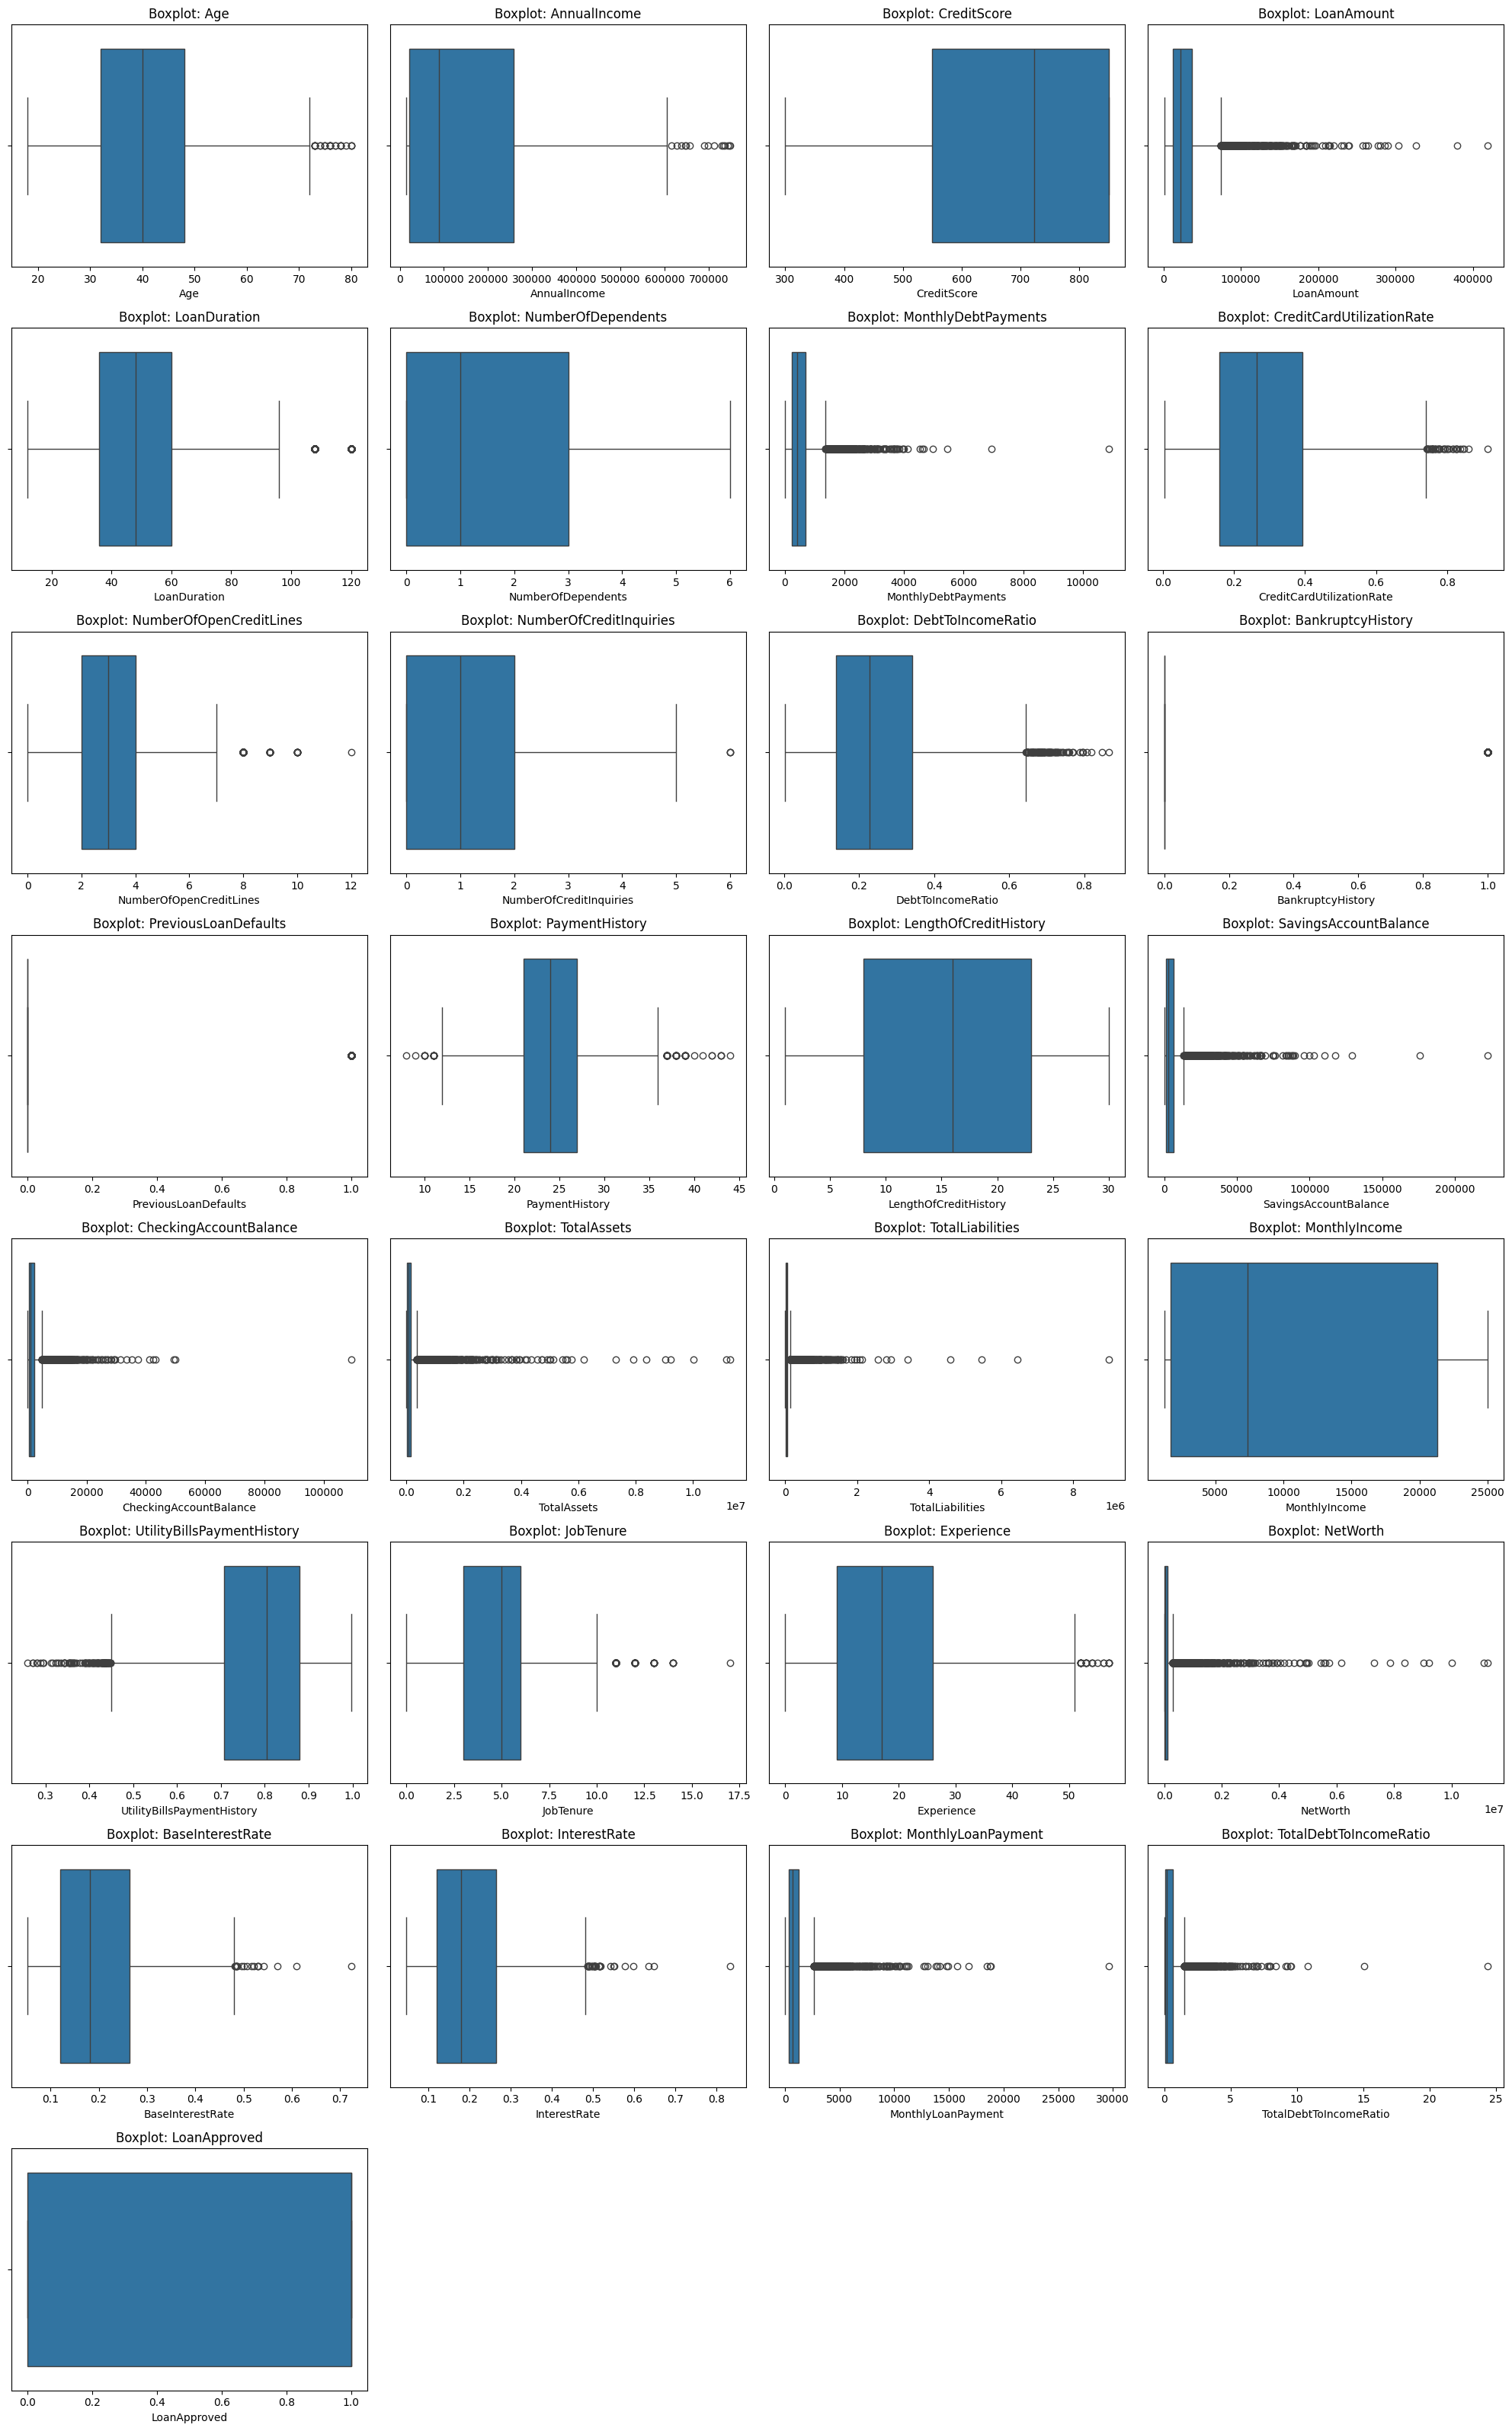

In [85]:
b_features = df_train.select_dtypes(include='number').columns.tolist()
if 'ID' in b_features:
    b_features.remove('ID')

n_features = len(b_features)
n_cols = 4 
n_rows = (n_features + n_cols - 1) // n_cols 
b_features = df_train.select_dtypes(include='number').columns.tolist()

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()

for idx, col in enumerate(b_features):
    sns.boxplot(x=df_train[col], ax=axes[idx])
    axes[idx].set_title(f'Boxplot: {col}')

for idx in range(n_features, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('boxplots_all.png', dpi=300, bbox_inches='tight')
plt.show()



это более развернутая иллюстрация . больше нужна для бининга( он у меня использовался в первой лабе)

**Обработка** 🦊

In [86]:
def bining_preprocess(df_in):
    df = df_in.copy()

    df  = df.drop('ApplicationDate', axis=1, errors='ignore')

    df['Age_cat'] = pd.cut(df['Age'], bins=[0, 25, 35, 50, 65, 100], labels=['very_young', 'young', 'middle', 'senior', 'old'])
    df = pd.get_dummies(df, columns=['Age_cat'], drop_first=True)


    df['Credit_tier'] = pd.cut(df['CreditScore'], bins=[0, 600, 700, 800, 1000], labels=['poor', 'fair', 'good', 'excellent'])
    df = pd.get_dummies(df, columns=['Credit_tier'], drop_first=True)


    df['Income_level'] = pd.qcut(df['MonthlyIncome'], q=4, labels=['low', 'medium', 'high', 'very_high'])
    df = pd.get_dummies(df, columns=['Income_level'], drop_first=True)

    df = pd.get_dummies(df, columns=['MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose', 'EmploymentStatus', 'EducationLevel'], drop_first=True)
    return df


БИНИНГ. Данные три категории можно визуально поделить на категории, с которыми грубо говоря работаем отдельною. Выбросы не так сильно влияют и мы можем уловить резкий переход. Я так же пробовала применить для некоторых других параметров применить бининг(например:AnnualIncome, но тогда MSE незначительно,но увеличивался). 

In [87]:
def category_preprocess(df):
    cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
    return df

По факту тут просходит One-Hot Encoding. При просмотре датасета  к категориальным признакам будуь отнесены: EmploymentStatus, EducationLeve, LoanPurpose, MaritalStatus,HomeOwnershipStatus.
Но я на всякий случай добавила имено отбор через object category

In [88]:
def create_financial_datas(df):
    df = df.copy()
    df['DebtBurdenIndicator'] = df['MonthlyDebtPayments'] / (df['MonthlyIncome'] + 1) #процент от дохода за месяц, который идет на долги
    df['AssetToIncome'] = df['TotalAssets'] / (df['AnnualIncome'] + 1) #отношение активов к доходу за год
    df['MonthSaving'] = df['SavingsAccountBalance'] / (df['MonthlyIncome'] + 1 ) #сбережения
    df['LoanToIncome'] = df['LoanAmount'] / (df['AnnualIncome'] + 1) #отношение кредита к доходу

    return df

Создаем дополнительные признаки,для большей информативности. Без доп параметров MSE застревал на 50 

In [89]:
# def mathop_preprocess(df):
#     df = df.copy()
#     log_features = ['AnnualIncome', 'LoanAmount', 'NetWorth', 'TotalDebtToIncomeRatio', 'MonthlyLoanPayment', 'CreditScore', 'MonthlyIncome', 'BaseInterestRate']
#     for feat in log_features:
#         if feat in df.columns:
#             df[f'{feat}_log'] = np.log1p(df[feat])
#     sqrt_features = ['TotalDebtToIncomeRatio', 'CreditScore', 'NetWorth', 'MonthlyIncome', 'TotalAssets']
#     for feat in sqrt_features:
#         if feat in df.columns:
#             df[f'{feat}_sqrt'] = np.sqrt(df[feat])
#     cbrt_features = ['TotalDebtToIncomeRatio', 'CreditScore', 'NetWorth', 'TotalAssets']
#     for feat in cbrt_features:
#         if feat in df.columns:
#             df[f'{feat}_cbrt'] = np.cbrt(df[feat])
#     inverse_features = ['InterestRate', 'BaseInterestRate', 'CreditScore']
#     for feat in inverse_features:
#         if feat in df.columns:
#             df[f'{feat}_inv'] = 1 / (df[feat] + 0.001)
#     return df

я убрала этот пайплайн из первой лабораторной. так как само обучение на этих доп признаках идет очень долго на моем железе. это не столь критично так как на кагле оба результаты были больше 0.75( далее они так же удалены при применении к датасету)

In [90]:
# def add_interactions_and_poly(df):
#     df = df.copy()
#     interactions = [
#         ('TotalAssets_sqrt', 'InterestRate', 'mul'),
#         ('TotalAssets_sqrt', 'InterestRate', 'div'),
#         ('TotalAssets_sqrt', 'TotalDebtToIncomeRatio', 'mul'),
#         ('TotalAssets_sqrt', 'TotalDebtToIncomeRatio', 'div'),
#         ('TotalAssets_sqrt', 'BaseInterestRate', 'mul'),
#         ('TotalAssets_sqrt', 'MonthlyLoanPayment', 'mul'),
#         ('TotalAssets_sqrt', 'MonthlyLoanPayment', 'div'),
#         ('TotalAssets_sqrt', 'BankruptcyHistory', 'mul'),
#         ('MonthlyIncome_sqrt', 'InterestRate', 'mul'),
#         ('MonthlyIncome_sqrt', 'InterestRate', 'div'),
#         ('MonthlyIncome_sqrt', 'TotalDebtToIncomeRatio', 'mul'),
#         ('MonthlyIncome_sqrt', 'TotalDebtToIncomeRatio', 'div'),
#         ('MonthlyIncome_sqrt', 'BaseInterestRate', 'mul'),
#         ('MonthlyIncome_sqrt', 'MonthlyLoanPayment', 'mul'),
#         ('MonthlyIncome_sqrt', 'MonthlyLoanPayment', 'div'),
#         ('MonthlyIncome_sqrt', 'BankruptcyHistory', 'mul'),
#         ('DebtServiceRatio', 'InterestRate', 'mul'),
#         ('AssetToIncomeRatio', 'LoanAmount', 'div'),
#         ('LoanToIncome', 'InterestRate', 'mul'),
#         ('BaseInterestRate', 'MonthlyLoanPayment', 'div'),
#         ('MonthlyIncome', 'InterestRate', 'div'),
#         ('MonthlyIncome', 'BaseInterestRate', 'div'),
#         ('LoanAmount', 'InterestRate', 'div'),
#         ('CreditCardUtilizationRate', 'InterestRate', 'mul'),
#     ]
#     for feat1, feat2, op in interactions:
#         if feat1 in df.columns and feat2 in df.columns:
#             if op == 'mul':
#                 df[f'{feat1}_mul_{feat2}'] = df[feat1] * df[feat2]
#             elif op == 'div':
#                 df[f'{feat1}_div_{feat2}'] = df[feat1] / (df[feat2] + 1e-6)
#     features_to_poly = [
#         'BaseInterestRate', 'InterestRate', 'TotalDebtToIncomeRatio',
#         'DebtToIncomeRatio', 'MonthlyLoanPayment', 'CreditScore', 'MonthlyIncome',
#         'LengthOfCreditHistory', 'DebtServiceRatio', 'LoanToIncome'
#     ]
#     for feature in features_to_poly:
#         if feature in df.columns:
#             df[f'{feature}_2'] = df[feature] ** 2
#             df[f'{feature}_3'] = df[feature] ** 3
#     return df


Делаем некое взаимодействиемежду парметрами. Некоторые из комбинаций могут влять сильнее чем по отдельности, тогда выясняются новые закономерности.
Полиномы помогают обойти проблемы с изгибами в кривой распределения

In [91]:
def preprocess_pipeline(df):
    df = df.drop('ApplicationDate', axis=1, errors='ignore')
    df = bining_preprocess(df)
    df = category_preprocess(df)
    df = create_financial_datas(df)
    # df = mathop_preprocess(df)
    # df = add_interactions_and_poly(df)
    return df


In [92]:

y_full = df_train['LoanApproved'].astype(int) 
X_full_raw = preprocess_pipeline(df_train.drop('LoanApproved', axis=1, errors='ignore'))

print(f"Класс 0: {(y_full == 0).sum()} ({(y_full == 0).mean()*100:.1f}%)")
print(f"Класс 1: {(y_full == 1).sum()} ({(y_full == 1).mean()*100:.1f}%)")


Класс 0: 4638 (48.7%)
Класс 1: 4891 (51.3%)


**Корреляционная матрица после преобразований** 🦊

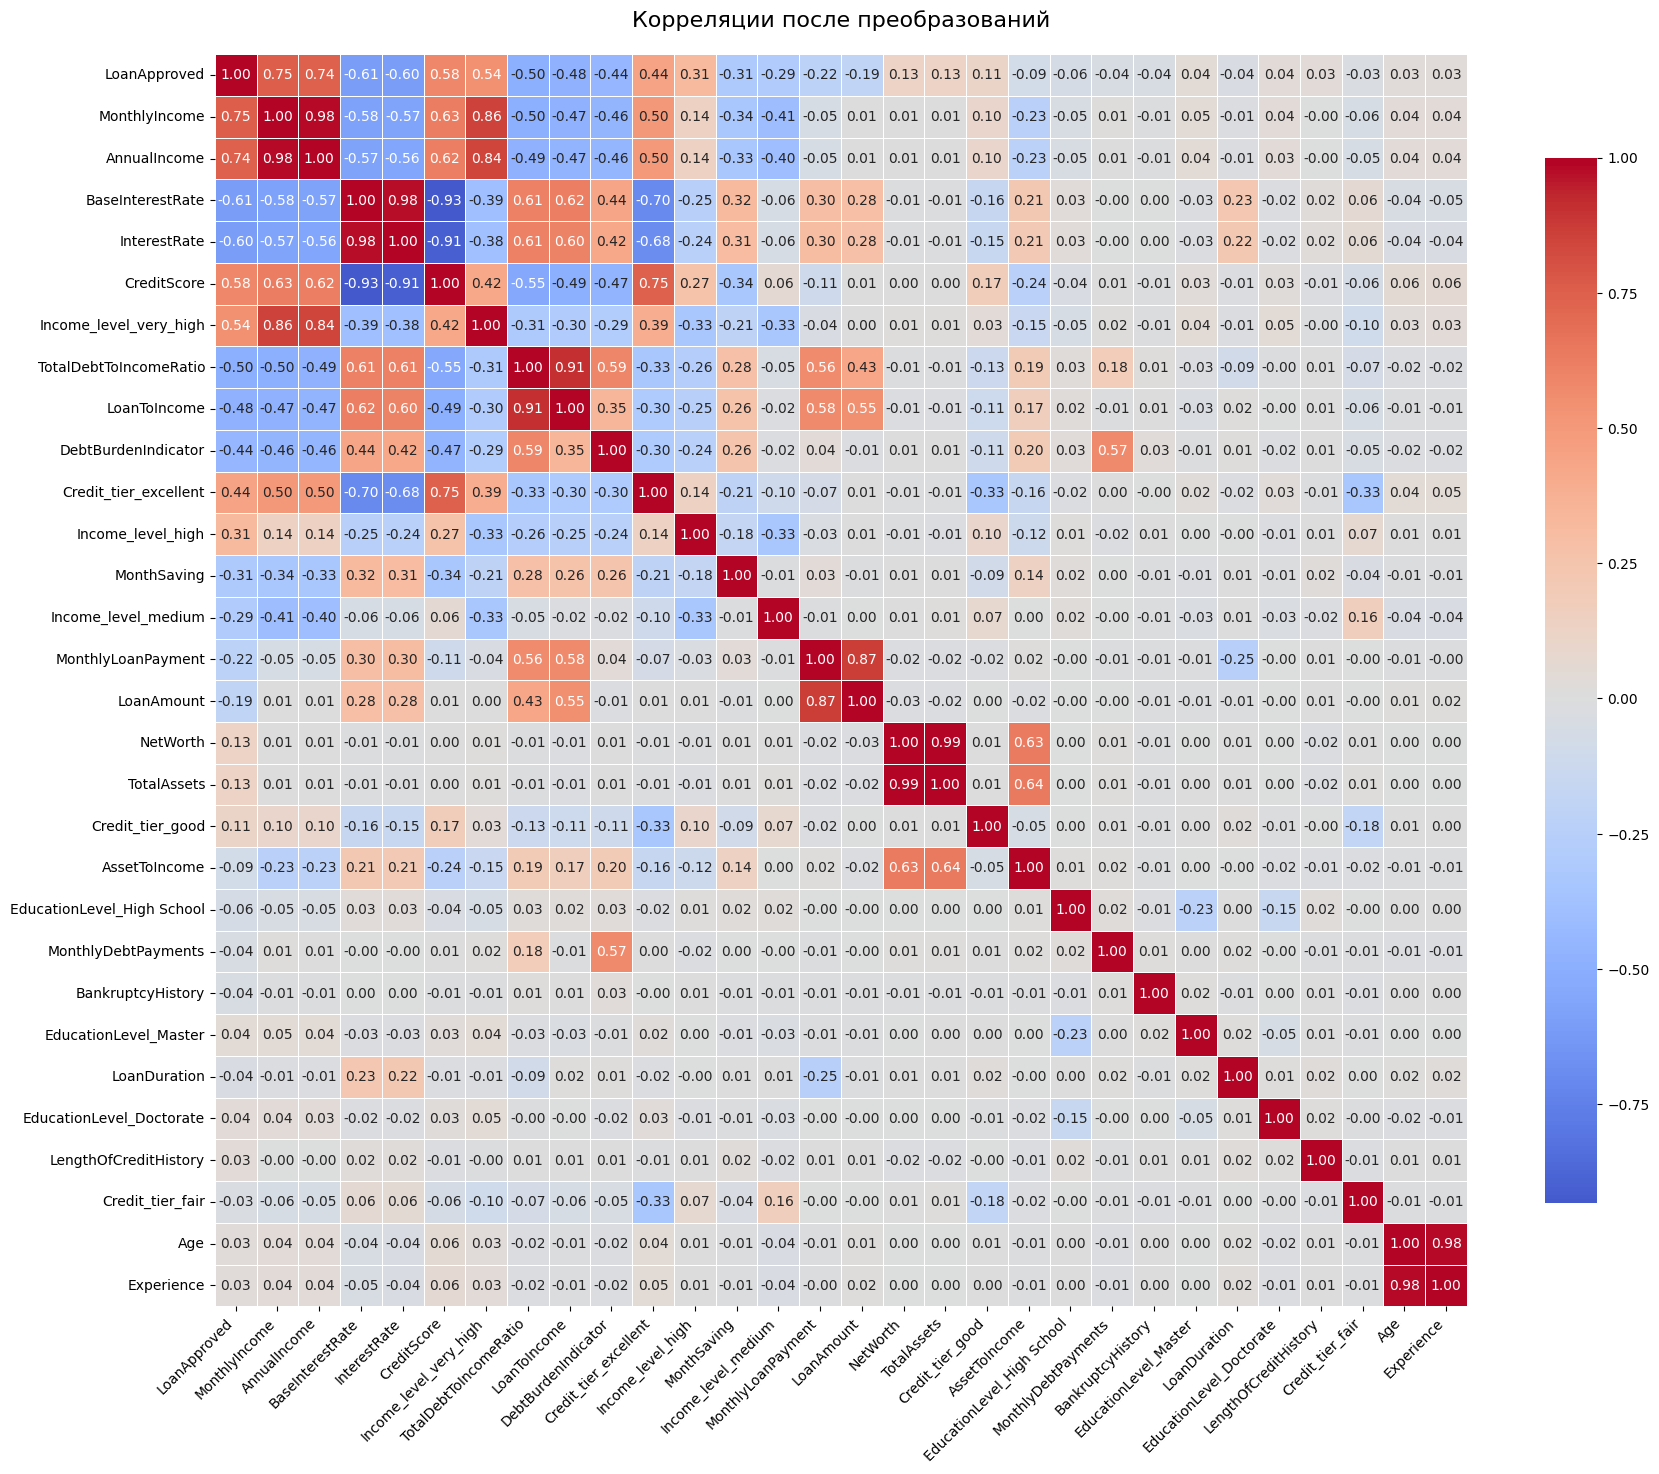

In [93]:
corr_post = X_full_raw.copy()
corr_post['LoanApproved'] = y_full.values 

corr_matrix = corr_post.corr()
top_features = corr_matrix['LoanApproved'].abs().sort_values(ascending=False).head(30).index  # ← ИЗМЕНЕНО!

plt.figure(figsize=(18, 15))
heatmap_fe = sns.heatmap(corr_post[top_features].corr(), 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": .8})
plt.title('Корреляции после преобразований', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_matrix_after', dpi=300, bbox_inches='tight')
plt.show()

**Boxplot после бининга** 🦊


медианы находятся в разных местах примерно везде - значит бининг был не напрасен

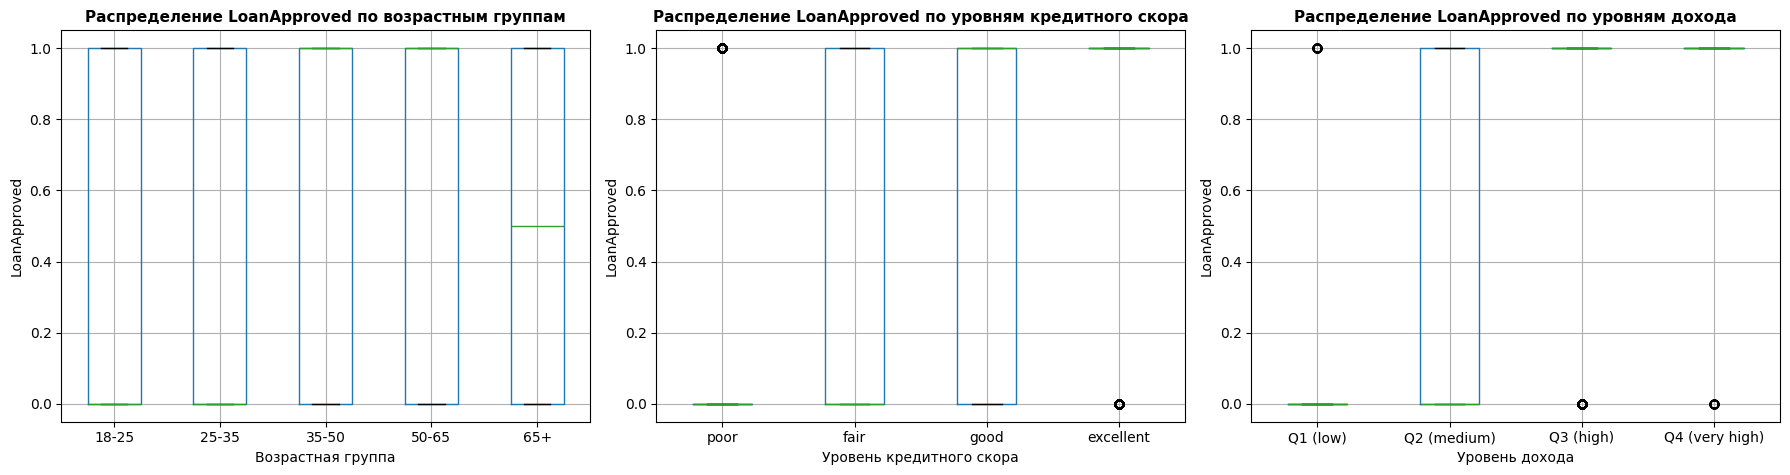

In [94]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

binned_age = pd.cut(df_train['Age'], bins=[0, 25, 35, 50, 65, 100], labels=['18-25', '25-35', '35-50', '50-65', '65+'])
df_plot_age = pd.DataFrame({'Age_group': binned_age, 'LoanApproved': df_train['LoanApproved']})
df_plot_age.boxplot(column='LoanApproved', by='Age_group', ax=axes[0])
axes[0].set_title('Распределение LoanApproved по возрастным группам', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Возрастная группа')
axes[0].set_ylabel('LoanApproved')
axes[0].get_figure().suptitle('')

binned_credit = pd.cut(df_train['CreditScore'], bins=[0, 600, 700, 800, 1000], labels=['poor', 'fair', 'good', 'excellent'])
df_plot_credit = pd.DataFrame({'Credit_tier': binned_credit, 'LoanApproved': df_train['LoanApproved']})
df_plot_credit.boxplot(column='LoanApproved', by='Credit_tier', ax=axes[1])
axes[1].set_title('Распределение LoanApproved по уровням кредитного скора', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Уровень кредитного скора')
axes[1].set_ylabel('LoanApproved')
axes[1].get_figure().suptitle('')


binned_income = pd.qcut(df_train['MonthlyIncome'], q=4, labels=['Q1 (low)', 'Q2 (medium)', 'Q3 (high)', 'Q4 (very high)'],  duplicates='drop')
df_plot_income = pd.DataFrame({'Income_level': binned_income, 'LoanApproved': df_train['LoanApproved']})
df_plot_income.boxplot(column='LoanApproved', by='Income_level', ax=axes[2])
axes[2].set_title('Распределение LoanApproved по уровням дохода', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Уровень дохода')
axes[2].set_ylabel('LoanApproved')
axes[2].get_figure().suptitle('')


plt.tight_layout()
plt.savefig('binning_after.png', dpi=300, bbox_inches='tight')
plt.show()

**Финальная подготовка и выбор модели** 🦊

я делю данные на три куска и подбираю гиперпараметры - так как без этого дробления у меня обучение и оптимизация занимала окло 20 минут . Но после того как выбрана лучшая параметры и лучшие параметры обучение уже просходит на всей части данных. Так же я выбрала только GridSearchCV, так как optuna так же долго работает на датасете

In [95]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
import numpy as np

print("\n" + "="*60)
print("КЛАССИФИКАЦИЯ - GridSearch ДЛЯ LOGREG И RANDOM FOREST")
print("="*60)
X_tune, _, y_tune, _ = train_test_split(
    X_full_raw, y_full,
    train_size=0.7,
    stratify=y_full,
    random_state=42
)
print(f"Размер данных для CV/тюнинга: {X_tune.shape}")

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

def cv_metrics(model, X, y, cv):
    aucs, precs, recs, f1s = [], [], [], []
    for train_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_tr, y_tr)
        y_pred_proba = model.predict_proba(X_val)[:, 1]
        y_pred = (y_pred_proba >= 0.5).astype(int)

        aucs.append(roc_auc_score(y_val, y_pred_proba))
        precs.append(precision_score(y_val, y_pred))
        recs.append(recall_score(y_val, y_pred))
        f1s.append(f1_score(y_val, y_pred))

    return np.mean(aucs), np.mean(precs), np.mean(recs), np.mean(f1s)

log_base = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)

param_grid_log = {
    'C': [0.1, 1.0, 10.0],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'] 
}

print("\n" + "-"*60)
print("GridSearchCV для Logistic Regression")
print("-"*60)

log_grid = GridSearchCV(
    estimator=log_base,
    param_grid=param_grid_log,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)
log_grid.fit(X_tune, y_tune)
best_log_params = log_grid.best_params_

print("\nЛучшие параметры Logistic Regression (GridSearchCV):")
print(best_log_params)
print(f"Лучший ROC-AUC (CV): {log_grid.best_score_:.4f}")

log_tuned = LogisticRegression(
    **best_log_params,
    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)
mean_auc, mean_prec, mean_rec, mean_f1 = cv_metrics(log_tuned, X_tune, y_tune, skf)
print("\nLogistic Regression (tuned) CV-метрики:")
print(f"  ROC-AUC:   {mean_auc:.4f}")
print(f"  Precision: {mean_prec:.4f}")
print(f"  Recall:    {mean_rec:.4f}")
print(f"  F1-score:  {mean_f1:.4f}")

rf_base = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, None],
    'min_samples_split': [2, 5]
}

print("\n" + "-"*60)
print("GridSearchCV для RandomForest")
print("-"*60)

rf_grid = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_tune, y_tune)
best_rf_params = rf_grid.best_params_

print("\nЛучшие параметры RandomForest (GridSearchCV):")
print(best_rf_params)
print(f"Лучший ROC-AUC (CV): {rf_grid.best_score_:.4f}")

rf_tuned = RandomForestClassifier(
    **best_rf_params,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
mean_auc, mean_prec, mean_rec, mean_f1 = cv_metrics(rf_tuned, X_tune, y_tune, skf)
print("\nRandom Forest (tuned) CV-метрики:")
print(f"  ROC-AUC:   {mean_auc:.4f}")
print(f"  Precision: {mean_prec:.4f}")
print(f"  Recall:    {mean_rec:.4f}")
print(f"  F1-score:  {mean_f1:.4f}")

model_candidates = {
    'Logistic Regression (tuned)': log_tuned,
    'Random Forest (tuned)': rf_tuned
}

metrics_results = {}
for name, model in model_candidates.items():
    print(f"\n Финальная проверка {name} на CV...")
    mean_auc, mean_prec, mean_rec, mean_f1 = cv_metrics(model, X_tune, y_tune, skf)
    metrics_results[name] = mean_auc
    print(f"  ROC-AUC:   {mean_auc:.4f}")
    print(f"  Precision: {mean_prec:.4f}")
    print(f"  Recall:    {mean_rec:.4f}")
    print(f"  F1-score:  {mean_f1:.4f}")

best_final_name = max(metrics_results, key=metrics_results.get)
print("\n" + "="*60)
print(f"ИТОГОВО ЛУЧШАЯ МОДЕЛЬ ПО CV: {best_final_name}")
print("="*60)

print("\n" + "="*60)
print("ФИНАЛЬНОЕ ОБУЧЕНИЕ И САБМИТ")
print("="*60)

if best_final_name.startswith('Logistic Regression'):
    final_model = LogisticRegression(
        **best_log_params,
        random_state=42,
        max_iter=1000,
        class_weight='balanced'
    )
else:
    final_model = RandomForestClassifier(
        **best_rf_params,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    )

final_model.fit(X_full_raw, y_full)

X_test_raw = preprocess_pipeline(df_train_test.drop('ID', axis=1, errors='ignore'))
X_test_raw = X_test_raw.reindex(columns=X_full_raw.columns, fill_value=0)

y_test_pred = final_model.predict_proba(X_test_raw)[:, 1]

submission = pd.DataFrame({
    'ID': test_id.values,
    'LoanApproved': y_test_pred
})

print("\n submission:")
print(submission.head(10))
print(f"\nПредсказания (среднее): {y_test_pred.mean():.4f}")
print(f"Предсказания (диапазон): {y_test_pred.min():.4f} - {y_test_pred.max():.4f}")
print(f"Количество строк: {len(submission)}")

submission.to_csv('submission.csv', index=False)
print("\n Файл сохранен: submission.csv")


КЛАССИФИКАЦИЯ - GridSearch ДЛЯ LOGREG И RANDOM FOREST
Размер данных для CV/тюнинга: (6670, 58)

------------------------------------------------------------
GridSearchCV для Logistic Regression
------------------------------------------------------------
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Лучшие параметры Logistic Regression (GridSearchCV):
{'C': 10.0, 'penalty': 'l1', 'solver': 'liblinear'}
Лучший ROC-AUC (CV): 0.9871

Logistic Regression (tuned) CV-метрики:
  ROC-AUC:   0.9870
  Precision: 0.9389
  Recall:    0.9331
  F1-score:  0.9360

------------------------------------------------------------
GridSearchCV для RandomForest
------------------------------------------------------------
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Лучшие параметры RandomForest (GridSearchCV):
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Лучший ROC-AUC (CV): 0.9802

Random Forest (tuned) CV-метрики:
  ROC-AUC:   0.9797
  Precision: 0.9211
 

как видно по оснвной метри ранжирования и по  доп метрикам точносты полноты и F1-score, Logistic Regression справляется на сотые доли лучше чем Random Forest


 МОДЕЛЬ ПО CV: Logistic Regression (tuned)


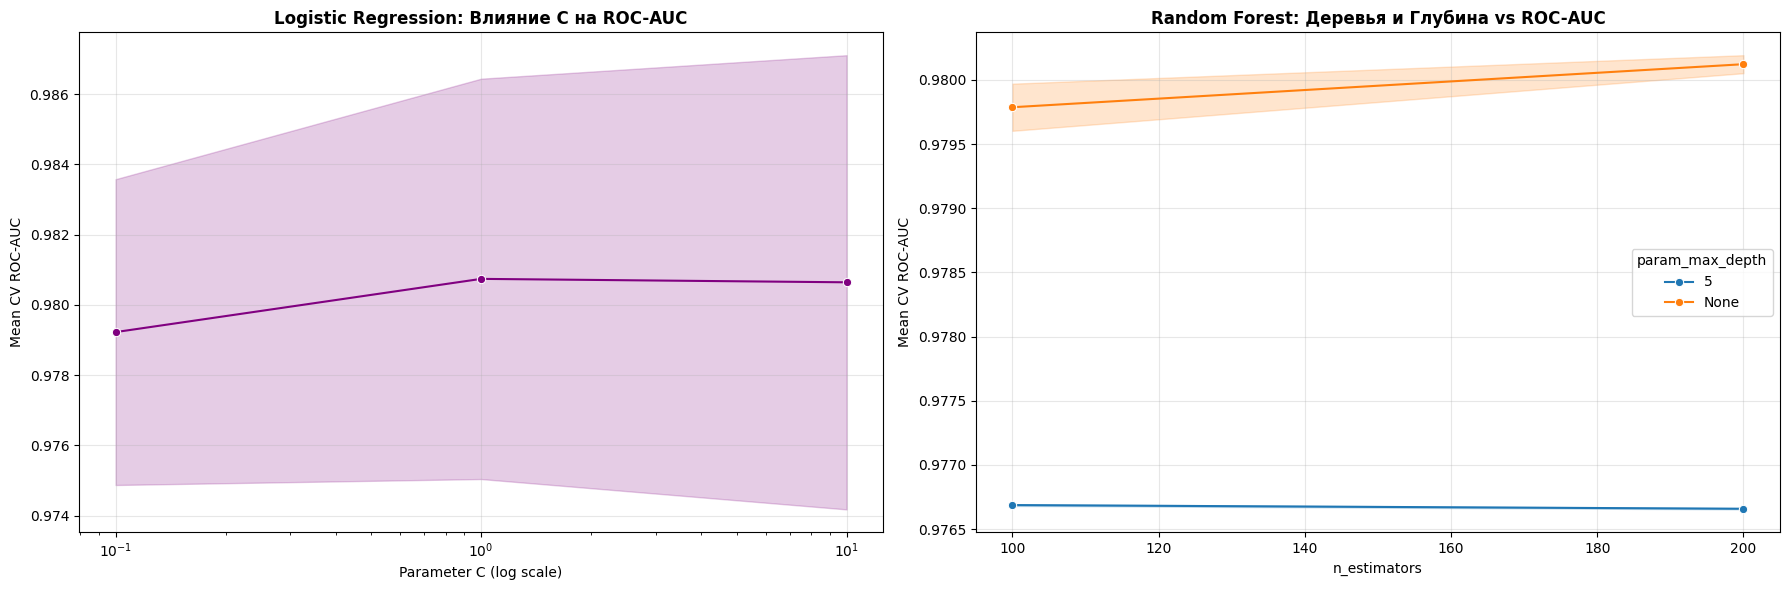


 СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ:


,Model,Best ROC-AUC,Best Params
0,Logistic Regression (Tuned),0.987107,"{'C': 10.0, 'penalty': 'l1', 'solver': 'liblin..."
1,Random Forest (Tuned),0.980192,"{'max_depth': None, 'min_samples_split': 2, 'n..."


In [96]:
best_final_name = max(metrics_results, key=metrics_results.get)
print("\n" + "="*60)
print(f" МОДЕЛЬ ПО CV: {best_final_name}")
print("="*60)

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

results_log = pd.DataFrame(log_grid.cv_results_)
sns.lineplot(data=results_log, x='param_C', y='mean_test_score', marker='o', color='purple', ax=axes[0])
axes[0].set_xscale('log')
axes[0].set_title('Logistic Regression: Влияние C на ROC-AUC', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Parameter C (log scale)')
axes[0].set_ylabel('Mean CV ROC-AUC')
axes[0].grid(True, alpha=0.3)

results_rf = pd.DataFrame(rf_grid.cv_results_)

results_rf['param_max_depth'] = results_rf['param_max_depth'].fillna('None')
sns.lineplot(data=results_rf, x='param_n_estimators', y='mean_test_score', hue='param_max_depth', marker='o', ax=axes[1])
axes[1].set_title('Random Forest: Деревья и Глубина vs ROC-AUC', fontsize=12, fontweight='bold')
axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('Mean CV ROC-AUC')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

summary_df = pd.DataFrame({
    'Model': ['Logistic Regression (Tuned)', 'Random Forest (Tuned)'],
    'Best ROC-AUC': [log_grid.best_score_, rf_grid.best_score_],
    'Best Params': [best_log_params, best_rf_params]
})
print("\n СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ:")
display(summary_df)

